In [1]:
import json
import math
import random
import torch



import os

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from tqdm.auto import tqdm


import matplotlib.pyplot as plt
import pandas as pd


In [2]:
from string import Template
import string
prompt_template= Template('''Instruct: Answer the following question using the context provided, reason over it because only one of the context is relevant . Please generate only answer choice (1, 2, 3, 4, 5, 6, 7 or 8) without any explanations\n
$question
context: $context      
                                                        
$options
$question
''')


In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
# device = "cuda"
# torch.set_default_device(device)
# BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
BASE_MODEL_ID = "microsoft/phi-2"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, trust_remote_code=True, device_map = "auto")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
val_data = []
with open("train.jsonl", "r") as f:
    data = f.readlines()

for line in data:
    val_data.append(json.loads(line))


test_data = []
with open("test.jsonl", "r") as f:
    data = f.readlines()

for line in data:
    test_data.append(json.loads(line))

In [5]:
print(val_data[0]["fact1"])
print(val_data[0]["fact2"])
print(val_data[0]["combinedfact"])




beads of water are formed by water vapor condensing
Clouds are made of water vapor.
Beads of water can be formed by clouds.


In [6]:
class MyLLMDataloader:
    def __init__(self, batch_size, tokenizer, data, shuffle = False, val= False):
        ## initializations
        self.batch_size  = batch_size
        self.tokenizer  = tokenizer
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.data = []
        self.val = val
        with open(data, "r") as f:
            test_data = f.readlines()
        if self.val:
            for line in test_data:
                self.data.append(json.loads(line))
        else:
             for line in test_data:
                self.data.append(json.loads(line))           
        # self.all_examples = list(self.data.keys())
        self.shuffle = shuffle
        # self.val = val
        
        self.n_data_points = math.ceil(len(self.data)/self.batch_size)
        print("datapoints",self.n_data_points , len(self.data))
        self.indices = [i for i in range(self.n_data_points)]
        
    def __getitem__(self, idx):
        ## this gets a batch 
        option_header = ["option 1 ", "option 2 ", "option 3 ", "option 4 ", "option 5 ","option 6 ", "option 7 ", "option 8 " ]

        batch_start_id = idx * self.batch_size
        batch_end_id  = min(len(self.data), batch_start_id + self.batch_size) 
        batch = {"question_context":[], "answer":[]}
        mapper_ans = {"A":1, "B":2, "C":3, "D":4, "E":5, "F":6, "G":7, "H":8}
        mapper_ans_inverted = {1:"a", 2:"b", 3:"c", 4:"d", 5:"e"}
        for i in range(batch_start_id, batch_end_id):
            example = self.data[i]
            options = []
            opts = []
            context = example["fact1"] + '\n' + example["fact2"]
            for i, sample in enumerate(example['question']['choices']):
                # print(key)
                if example["answerKey"] == sample["label"]:
                    correct_option_id = mapper_ans[example["answerKey"]]
                    correct_option_txt = sample["text"]
                
                     
            
                # options.append(option_header[i]+ sample['text'])
                options.append(sample['text'])

                opts.append((sample['text'], option_header[i].split("option")[1]))
             

            explanation = example['combinedfact']

            # explanation = ''
            # if example["exp"] != None:
            #     explanation  = example["exp"]
          
           

            if self.shuffle:
                random.shuffle(options)
                correct_option_id = options.index(correct_option_txt) +1
            
                options_with_header = [option_header[i] +options[i] for i in range(len(options)) ]
                options_with_header = "\n".join(options_with_header)
                # correct_option_txt = example["answer"].split(": ")[1]
                # correct_option_txt = example["answer"][10:]

                correct_option_txt_header = str(correct_option_id) + " " + correct_option_txt


                prompt = prompt_template.substitute( question  = example['question']['stem'], context=  context, options = options_with_header) + "option"
              

            else:
                correct_option_id = correct_option_id
                correct_option_txt_header = str(correct_option_id) + " " + correct_option_txt
                options_with_header = [option_header[i] +options[i] for i in range(len(options)) ]
                options_with_header = "\n".join(options_with_header)
                prompt =prompt_template.substitute( question  = example['question']['stem'], context=  context, options = options_with_header)+ "option"


            correct_option_txt_header += '\n' + 'explanation: ' + explanation
           
            ## context TBD
            # answer =  f"{correct_option_txt_header}  \nExplanation: {example['explanation']}"
            
            # if not self.val:
            #     answer =  f"{correct_option_txt_header}  \nExplanation: {explanation}"
            # else:
            #     answer =  f"{correct_option_txt_header}"



            # print(prompt, answer)
            batch["question_context"] += [prompt]

            batch["answer"] += [correct_option_txt_header]

        self.tokenizer.padding_side = "left"
        q_tokens = self.tokenizer(batch["question_context"], padding="longest", return_tensors="pt")  
        self.tokenizer.padding_side = "right"
        a_tokens = self.tokenizer(batch["answer"], padding="longest", return_tensors="pt")
        tokens = torch.cat([q_tokens["input_ids"], a_tokens["input_ids"]], dim=1)
        attn_masks = torch.cat([q_tokens["attention_mask"], a_tokens["attention_mask"]], dim=1)
        loss_mask = torch.cat([torch.zeros_like(q_tokens["attention_mask"]), a_tokens["attention_mask"]], dim=1)[:,1:]
   
        result = {
        "inp_ids":tokens[:,:-1],
        "inp_mask":attn_masks[:,:-1],## Causal Training
        "out_ids":tokens[:,1:], ## Causal Labels
        "out_mask":attn_masks[:,1:],
        "q_tokens": q_tokens,
        "a_tokens": a_tokens,}
        result["loss_mask"] = loss_mask * result["out_mask"]
        # result["out_ids"][:,:q_tokens["input_ids"].size(1)-10] = self.tokenizer.eos_token_id

        return result       


            

    def __iter__(self):
        self.idx = 0
        return self

    def __next__(self):
        if self.idx >= self.n_data_points:
            self.idx = 0
            raise StopIteration
        temp_idx = self.indices[self.idx]
        self.idx += 1
        return self[temp_idx]
             








            




    
    def __len__(self):
        return self.n_data_points
    



        

In [7]:
# with open("train5000_cleaned.json", "r") as f:
#     test_data = f.readlines()

# print(len(test_data))

In [8]:
train_data = MyLLMDataloader(1, tokenizer, "train.jsonl", val=False, shuffle=True)
for item in train_data:
    # print(item)
    break
# valLoader = MyLLMDataloader(1, tokenizer, "questions_365_val.json", val=True, shuffle=False)
#     # if int(tokenizer.decode(item["a_tokens"].input_ids[:,0], skip_special_tokens=True)) ==0:
#     print(tokenizer.decode(item['inp_ids'][0])),
#     print(tokenizer.decode(item["a_tokens"].input_ids[:,0], skip_special_tokens=True))
#     break

datapoints 8134 8134


In [9]:
train_data = MyLLMDataloader(4, tokenizer, "dev.jsonl", shuffle=False)
for item in train_data:
    # print(item)
    break

datapoints 232 926


In [10]:
def forward_pass(model, batch):
    inp_ids = batch["inp_ids"].to(model.device)
    attn_mask = batch["inp_mask"].to(model.device)
    result = model(input_ids=inp_ids, attention_mask=attn_mask)
    logits = result.logits
    return logits


def calc_loss(loss_fn, logits, batch):
    B, L, C = logits.shape
    target = batch["out_ids"].to(logits.device)
    mask = batch["loss_mask"].to(logits.device)
    loss = loss_fn(logits.reshape(-1, C), target.reshape(-1)) * mask.reshape(-1)
    loss = loss.sum()/mask.sum()
    return loss

def update(model, optimizer, loss_fn, batch, accumulate_grad=True):
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        logits = forward_pass(model, batch)
        loss = calc_loss(loss_fn, logits, batch)
    
    scaler.scale(loss).backward()
    if not accumulate_grad:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
    return loss.item(), logits




def train_on_batches(model, train_data_loader, optimizer, loss_fn, grad_accum_bs=16):
    train_loss = 0
    score = 0
    num_correct = 0
    total_num = 0
    mapper_ans = {"A":1, "B":2, "C":3, "D":4, "E":5}

    pbar = tqdm(range(len(train_data_loader)))
    option_ids = [tokenizer(o).input_ids[0] for o in ["A", "B", "C", "D", "E", "F","G", "H"]]
    model.train()
    for i,batch in enumerate(train_data_loader):
        grad_step_bs = grad_accum_bs/train_data_loader.batch_size
        if (i>=grad_step_bs and i%grad_step_bs == 0) or i == len(train_data_loader)-1:
            accumulate_grad = False
        else:
            accumulate_grad = True
        loss, logits = update(model, optimizer, loss_fn, batch, accumulate_grad=accumulate_grad)
        train_loss += (1/(i+1))*(loss-train_loss)
        # if i% 50 == 0:
        #     print(logits.shape, logits[:,batch["q_tokens"].input_ids.size(1)-1,option_ids].shape, logits[ :,batch["q_tokens"].input_ids.size(1)-1:  ].shape, train_data_loader.tokenizer.batch_decode(logits[ :,batch["q_tokens"].input_ids.size(1)-1:  ].argmax(dim=2)))
        pred = (logits[:,batch["q_tokens"].input_ids.size(1)-1,option_ids].argmax(dim=1) + 1).tolist()
        target = train_data_loader.tokenizer.batch_decode(batch["a_tokens"].input_ids[:,0], skip_special_tokens=True)
        for p,t in zip(pred, target):
            total_num += 1
            # print('p', p, 't',t)
            # t = mapper_ans[t]

            num_correct += (int(p) == int(t))
            score = num_correct/total_num
        

        pbar.set_description(f"Train Loss: {train_loss:.4f} Score: {score:.4f}")
        pbar.update(1)
    pbar.close()

    return train_loss, score



In [11]:
def train(model, tdataloader,vdataloader, optimizer, loss_fn, scheduler, epochs=3, log_dir="logs/phi_qasc"):
    os.makedirs(log_dir, exist_ok=True)
    with open(f"{log_dir}/train.txt", "w") as tf, open(f"{log_dir}/val.txt", "w") as vf:
        tf.write(f"Epoch,Loss,Score\n")
        vf.write("Epoch,Loss,Score\n")
    best_val_score = 0
    
    for epoch in range(1,1+epochs):
        train_loss, tscore = train_on_batches(model, tdataloader, optimizer, loss_fn, grad_accum_bs=16)
        scheduler.step()
        val_loss, score = validation(model, vdataloader, loss_fn)
        with open(f"{log_dir}/train.txt", "a+") as tf, open(f"{log_dir}/val.txt", "a+") as vf:
            tf.write(f"{epoch},{train_loss},{tscore}\n")
            vf.write(f"{epoch},{val_loss},{score}\n")
        lr = optimizer.param_groups[0]["lr"]
        tqdm.write(f"Epoch: {epoch} | LR: {lr:.7f} | Train Loss: {train_loss:.4f} | Train Score: {tscore:.4f} | Val Loss: {val_loss:.4f} | Val Score: {score:.4f}")
        
        if score > best_val_score:
            model.save_pretrained(log_dir+"/model")
            best_val_score = score

        # update the learning rate
        # for param_group in optimizer.param_groups:
        #     param_group['lr'] = 1.0*float(param_group['lr'])

        train_df = pd.read_csv(f"{log_dir}/train.txt")
        val_df = pd.read_csv(f"{log_dir}/val.txt")

        fig, ax = plt.subplots(1, 2, figsize=(20,8))
        ax[0].plot(range(1,len(train_df)+1), train_df["Loss"], label="Train")
        ax[0].plot(range(1,len(val_df)+1), val_df["Loss"], label="Val")

        ax[1].plot(range(1,len(train_df)+1), train_df["Score"], label="Train")
        ax[1].plot(range(1,len(val_df)+1), val_df["Score"], label="Val")

        ax[0].set_xlabel("Epochs")
        ax[1].set_xlabel("Epochs")

        ax[0].set_ylabel("Loss")
        ax[1].set_ylabel("Score")

        ax[0].legend()
        ax[1].legend()

        fig.suptitle('', fontsize=16)
        fig.savefig("plt.png")


def validation(model, val_data_loader, loss_fn):
    val_loss = 0
    mapper_ans = {"A":1, "B":2, "C":3, "D":4, "E":5}

    score = 0
    num_correct = 0
    pbar = tqdm(range(len(val_data_loader)))
    option_ids = [tokenizer(o).input_ids[0] for o in ["A", "B", "C", "D", "E", "F","G", "H"]]
    total_num = 0
    model.eval()
    with torch.inference_mode():
        for i, batch in enumerate(val_data_loader):
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = forward_pass(model, batch)
                loss = calc_loss(loss_fn, logits, batch).item()
            val_loss += (1/(i+1))*(loss - val_loss)
            pred = (logits[:,batch["q_tokens"].input_ids.size(1)-1,option_ids].argmax(dim=1) + 1).tolist()
            target = val_data_loader.tokenizer.batch_decode(batch["a_tokens"].input_ids[:,0], skip_special_tokens=True)
            for p,t in zip(pred, target):
             
                total_num += 1
                # t = mapper_ans[t]
                num_correct += (int(p) == int(t))
                score = num_correct/total_num
                
            pbar.set_description(f"Val Loss: {val_loss:.4f} Score: {score:.4f}")
            pbar.update(1)
            
        gen_tokens = model.generate(**batch["q_tokens"].to(model.device), max_new_tokens=10)[:,batch["q_tokens"].input_ids.size(1):]
        gen_txt = val_data_loader.tokenizer.batch_decode(gen_tokens, skip_special_tokens=True)
        target_txt = val_data_loader.tokenizer.batch_decode(batch["a_tokens"].input_ids, skip_special_tokens=True)
        tqdm.write("Target: " + "\n" + "\n".join(target_txt) + "\nGenerated: \n " + "\n".join(gen_txt) +"\n")
        pbar.close()

    return val_loss, score


datapoints 4067 8134
datapoints 926 926


/tmp/ipykernel_50390/1526728197.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler =  torch.cuda.amp.GradScaler(enabled=True)


  0%|          | 0/4067 [00:00<?, ?it/s]

  0%|          | 0/926 [00:00<?, ?it/s]

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

Target: 
4 dialysis
explanation: Renal failure may be treated with dialysis
Generated: 
 4 dialysis
explanation: renal failure

Epoch: 9 | LR: 0.0000283 | Train Loss: 0.1372 | Train Score: 0.4071 | Val Loss: 0.2575 | Val Score: 0.4600


  0%|          | 0/4067 [00:00<?, ?it/s]

  0%|          | 0/926 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Target: 
4 dialysis
explanation: Renal failure may be treated with dialysis
Generated: 
 4 dialysis
explanation: Renal

Epoch: 10 | LR: 0.0000188 | Train Loss: 0.1294 | Train Score: 0.4088 | Val Loss: 0.2596 | Val Score: 0.4363


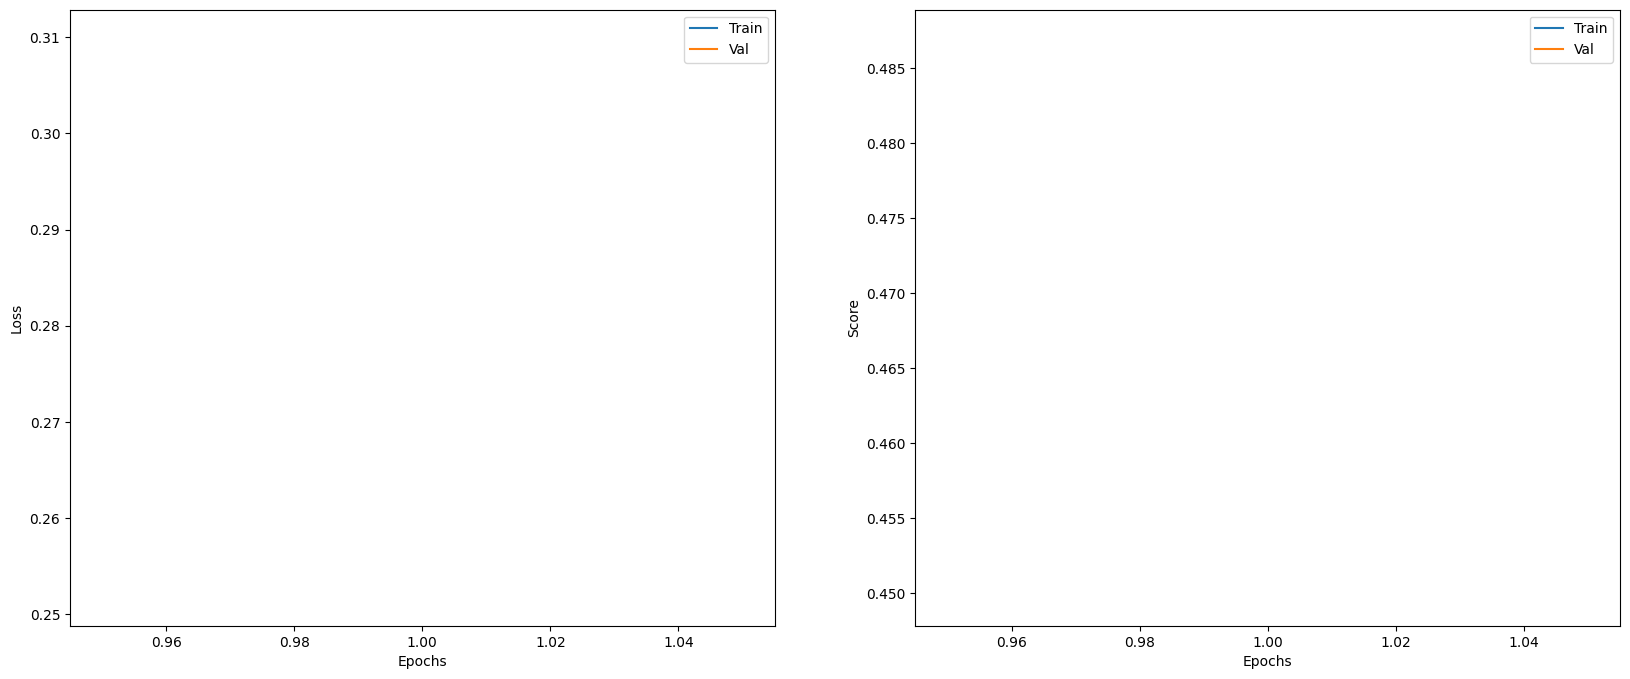

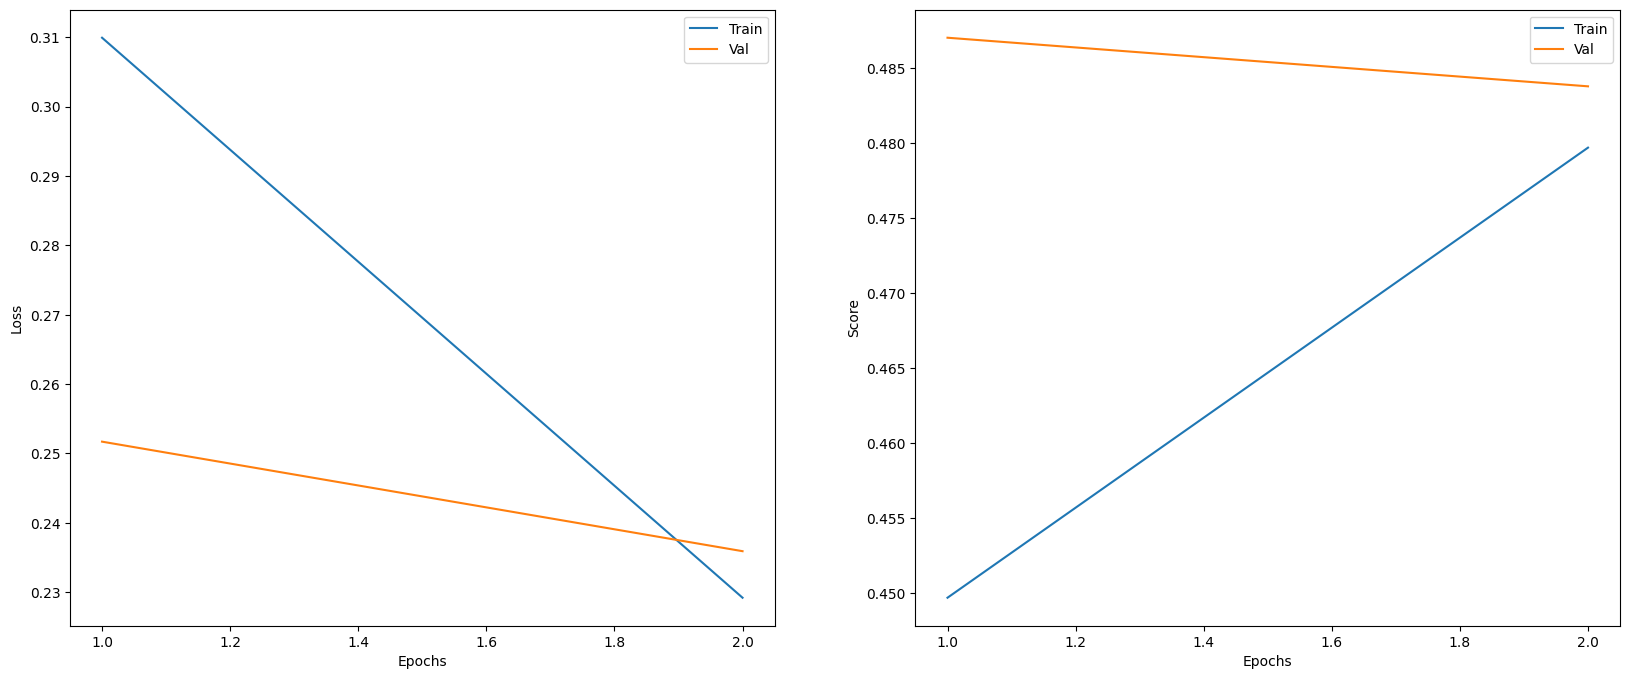

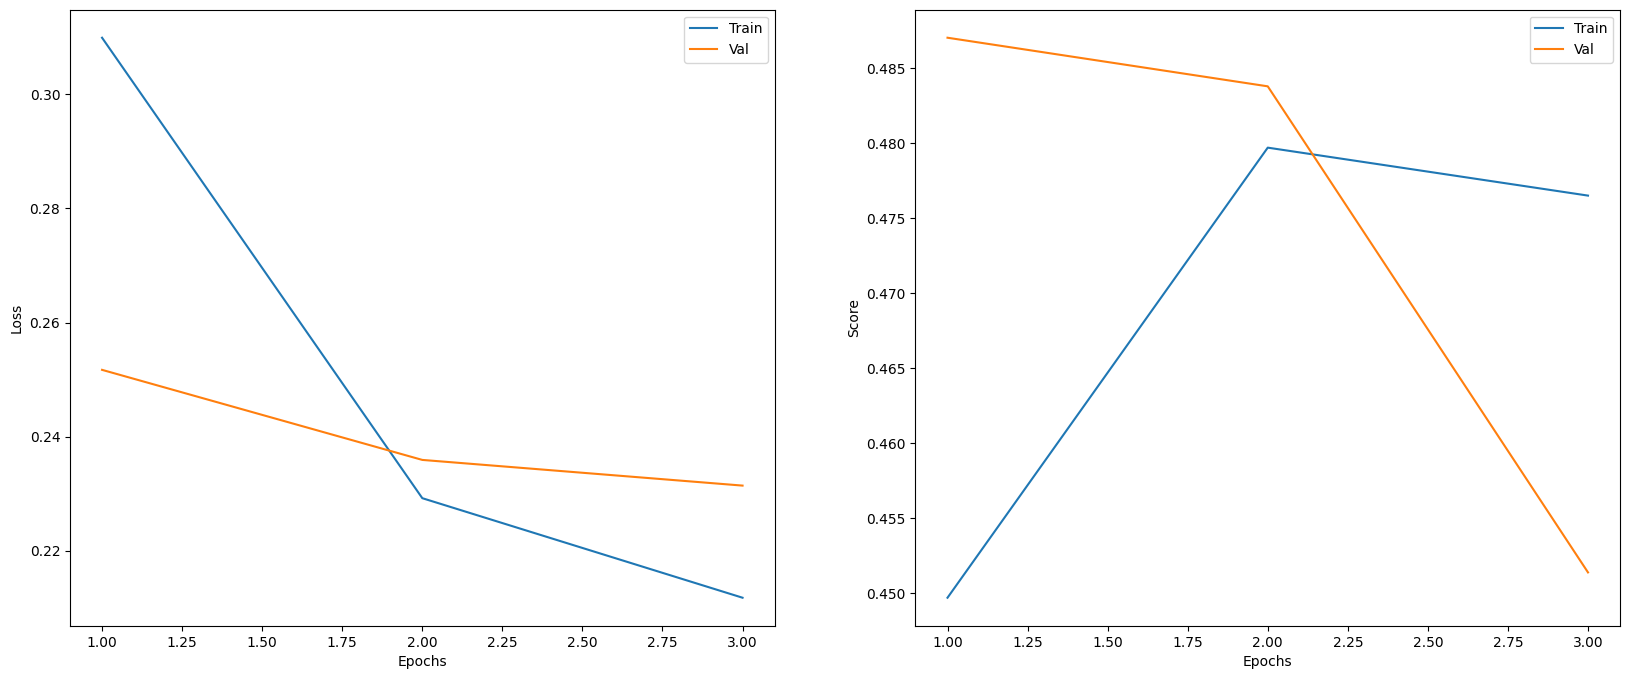

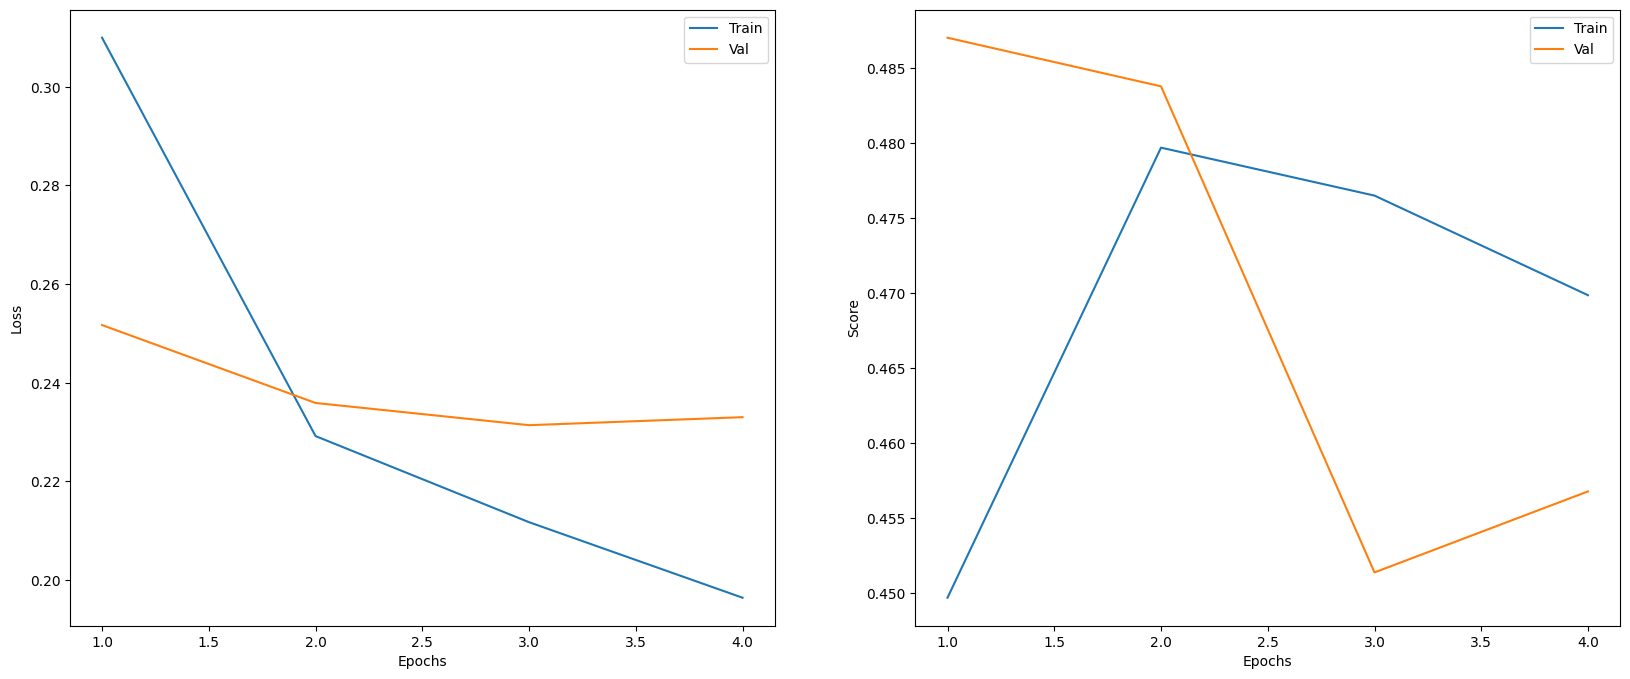

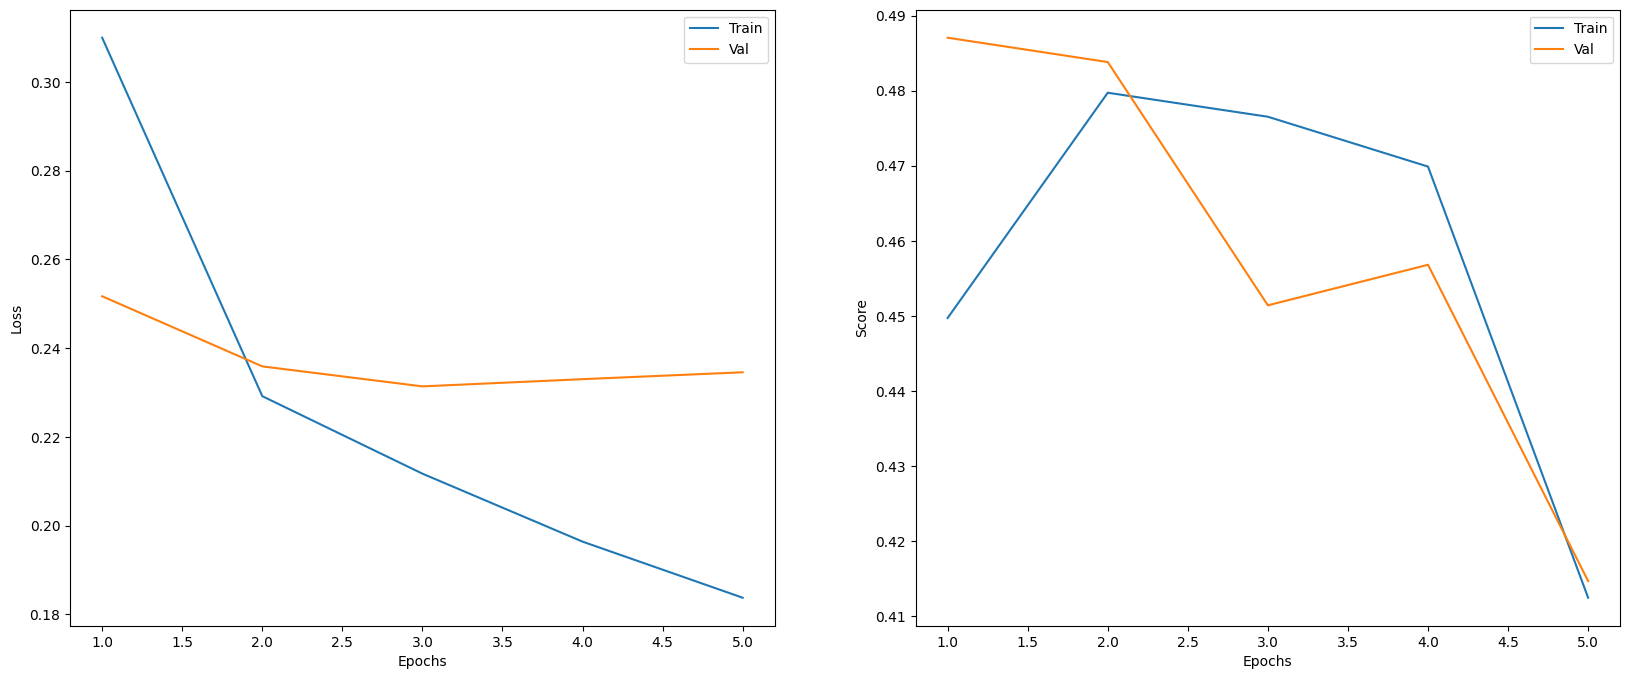

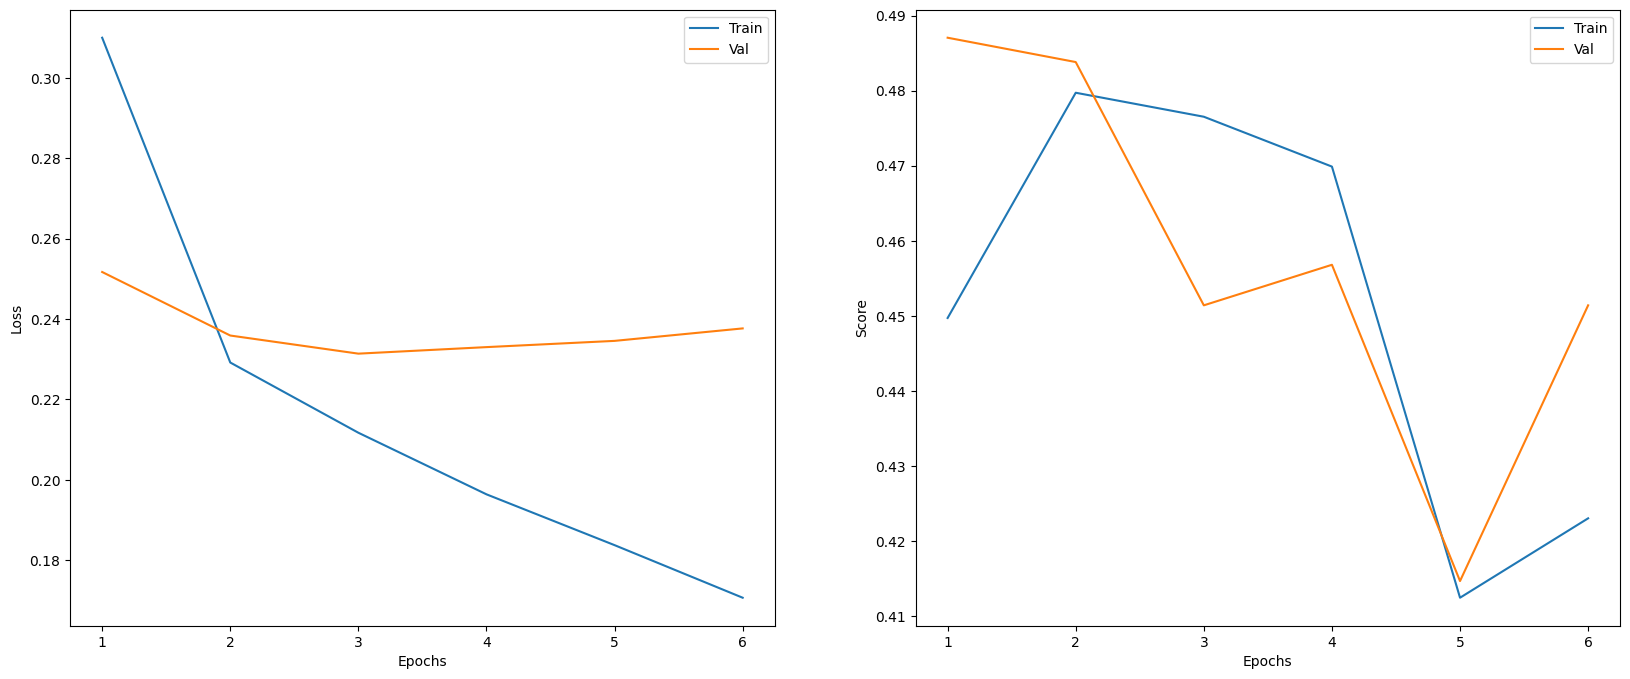

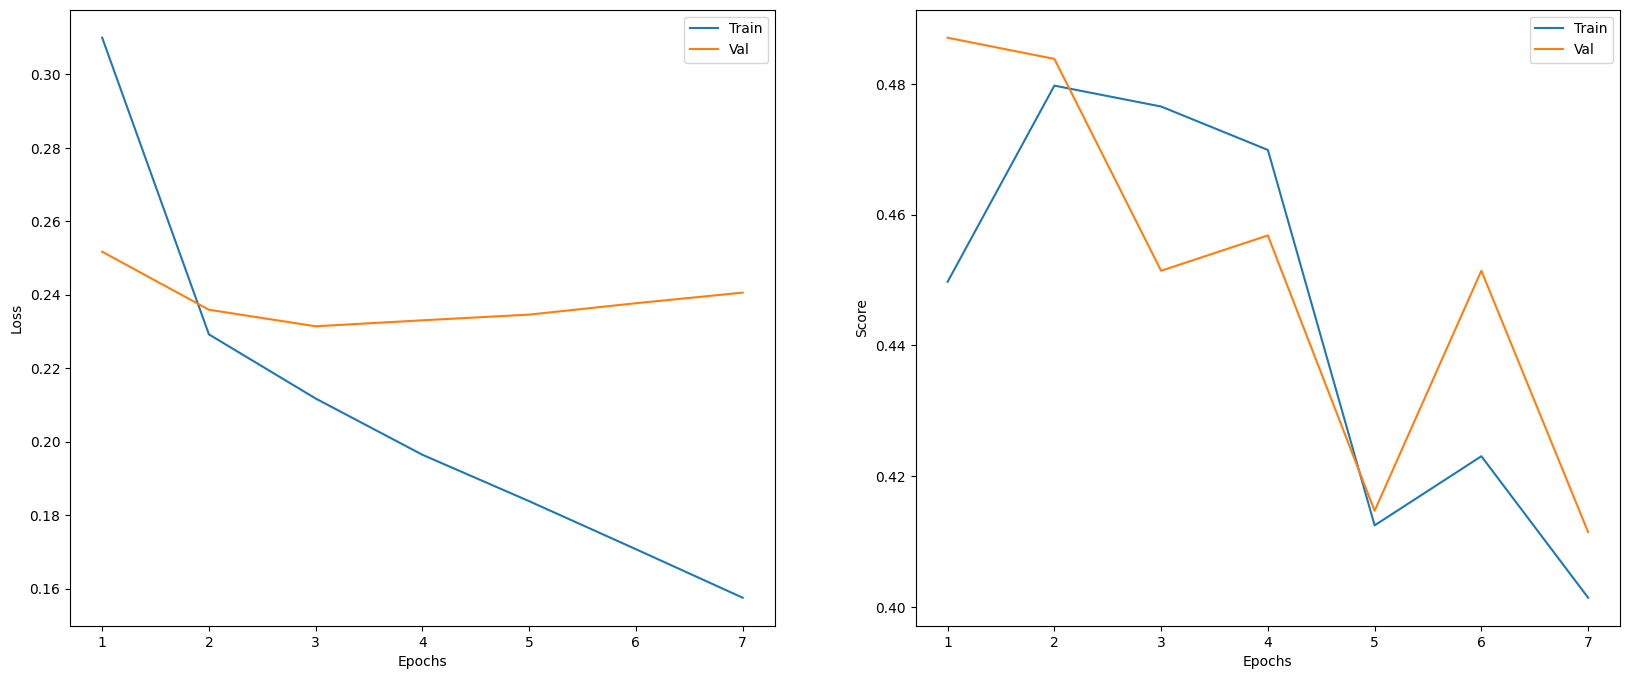

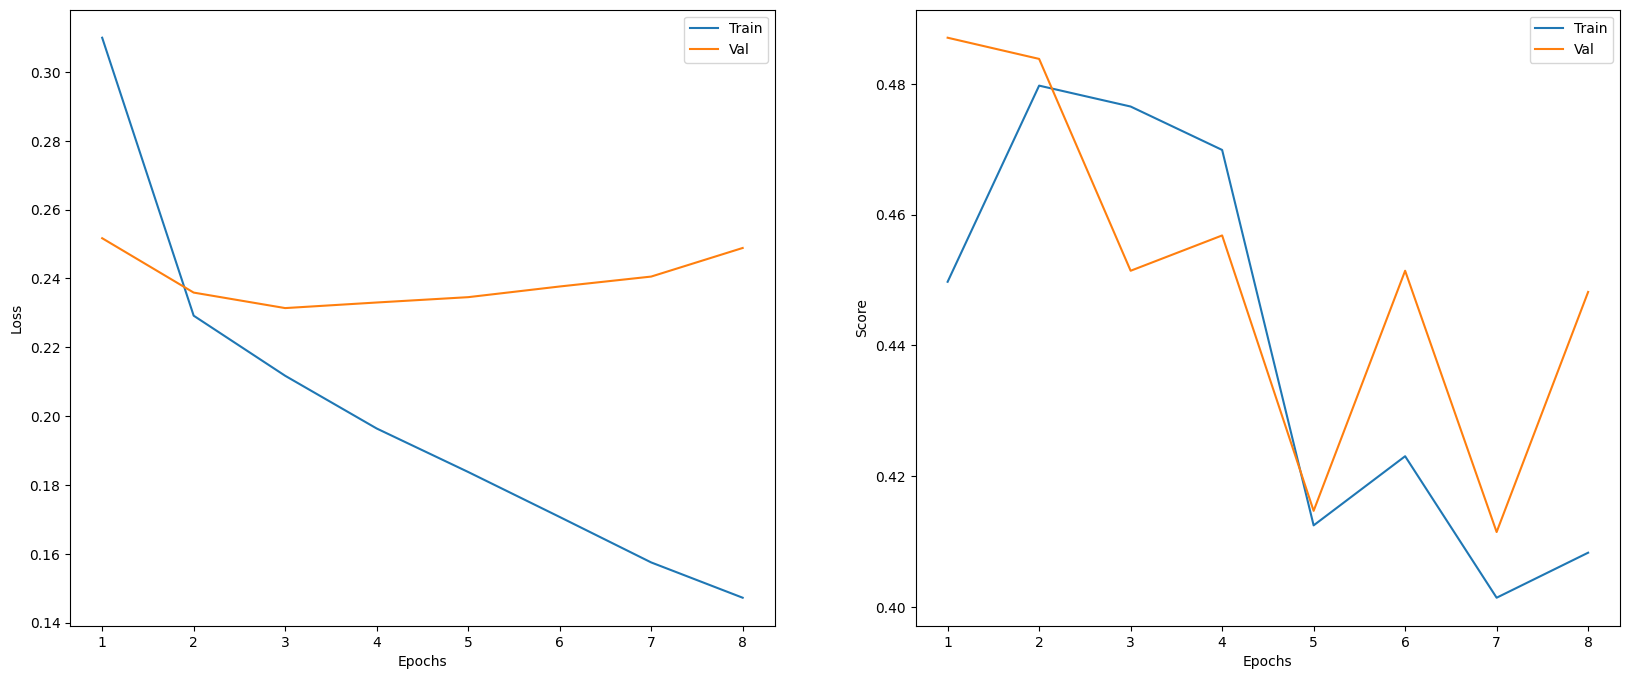

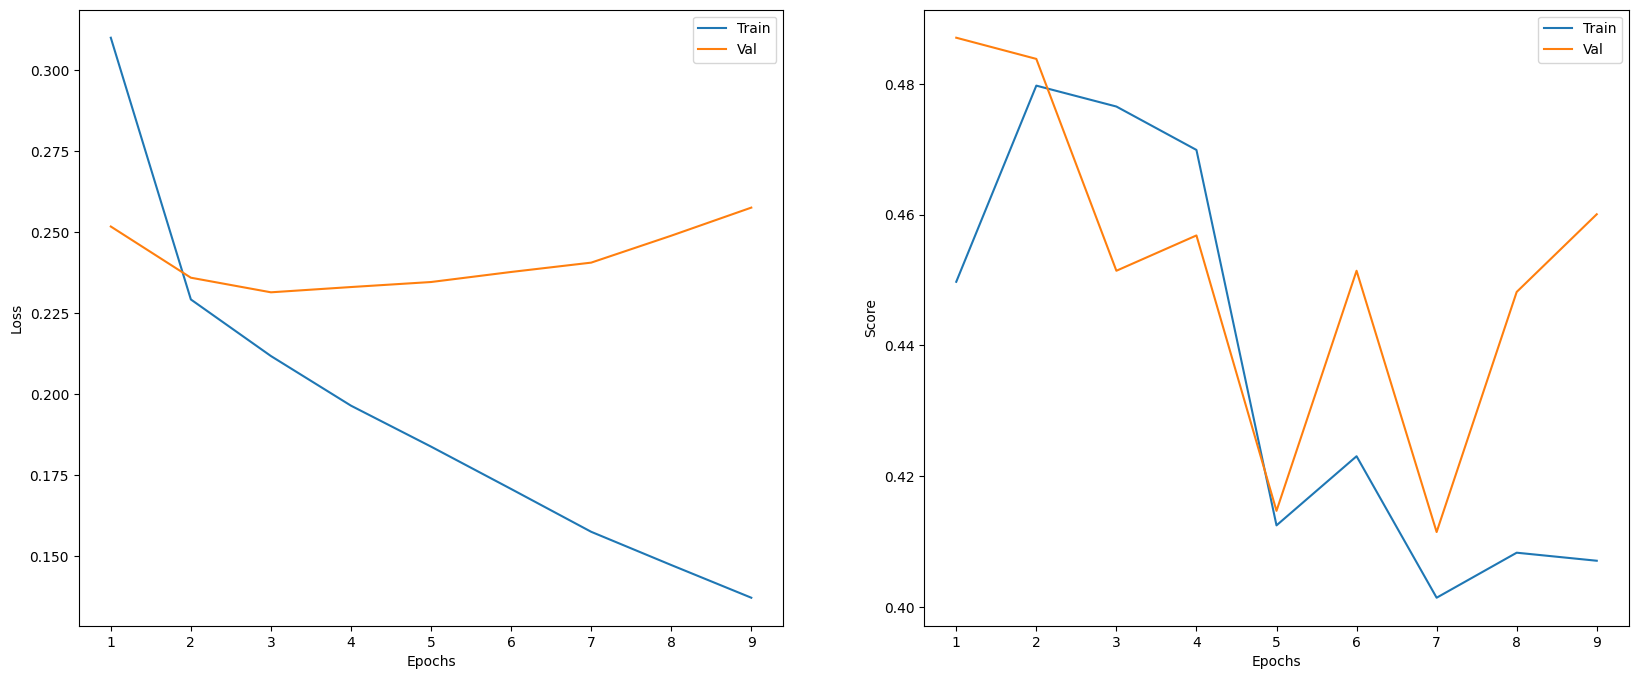

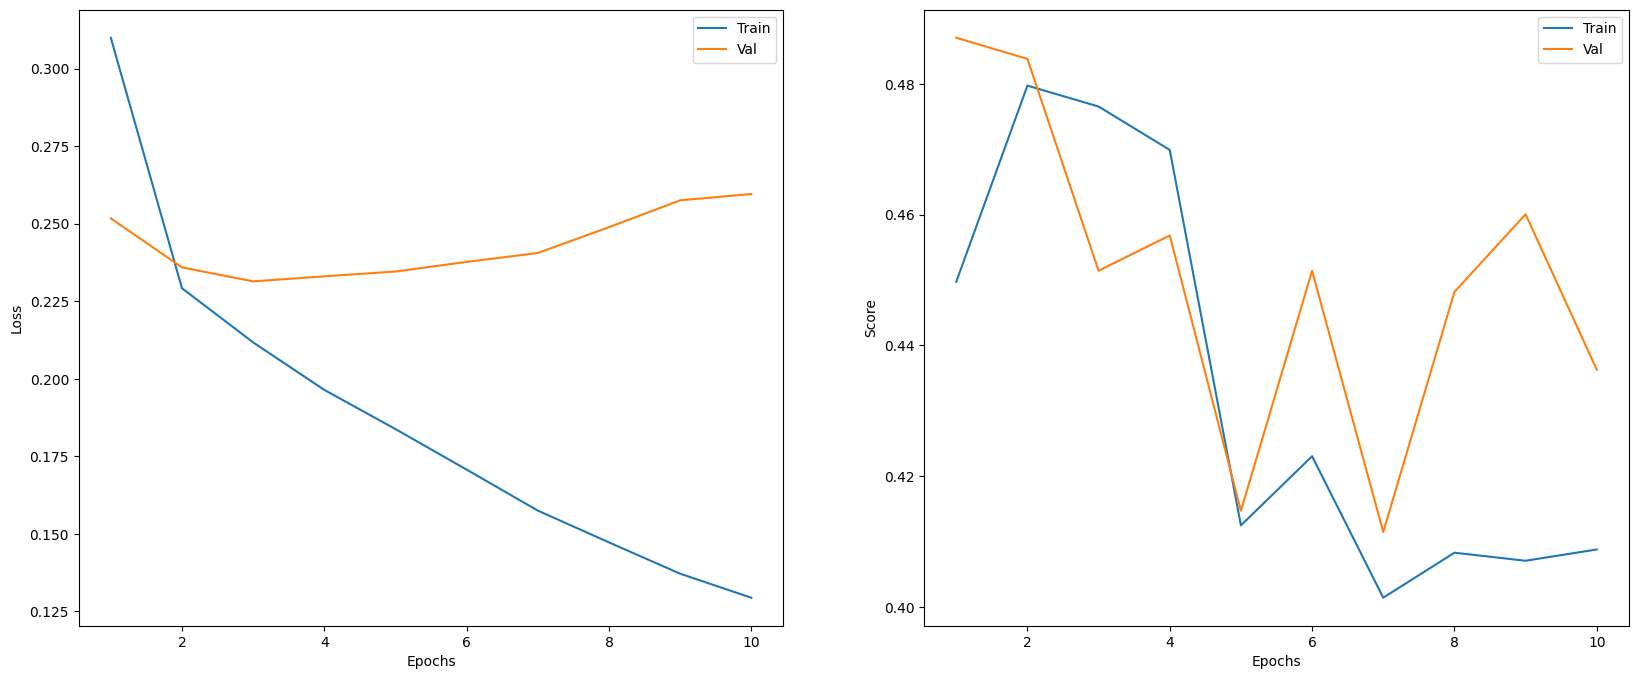

In [12]:
# device = "cuda"
# torch.set_default_device(device)
# tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
# model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, trust_remote_code=True, device_map ="auto")
epochs = 7
lr = 1e-4
peft_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=64,  # reduce if running into out-of-memory issues
    lora_alpha=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'dense'],
    # modules_to_save=["lm_head"],
    lora_dropout=0.05,
)
model = get_peft_model(model, peft_config)
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=tokenizer.eos_token_id, reduction='none').cuda()
optimizer = torch.optim.AdamW(model.parameters(), lr, weight_decay= 0.001)
optimizer.zero_grad()


# trainLoader = TrainDataLoader(2, tokenizer, topk=topk)
trainLoader = MyLLMDataloader(2, tokenizer, "train.jsonl", val=False, shuffle=True)

valLoader = MyLLMDataloader(1, tokenizer, "dev.jsonl", val=True)
scaler =  torch.cuda.amp.GradScaler(enabled=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
            T_max = epochs*2, eta_min=1E-8)
train(model, trainLoader, valLoader,optimizer, loss_fn, scheduler, epochs=10)



In [13]:
torch.cuda.empty_cache()
import gc
gc.collect()

76265

In [14]:
# train_loader = torch.utils.data.DataLoader(train_data, num_workers=2, batch_size =1,)


In [15]:
# with open('cleaned_TeleQnA_train_context_gte.json', 'r') as f:
#     new_train = f.read()

# new_train = json.loads(new_train)


# with open('TeleQnA_training.json', 'r') as f:
#     old_train = f.read()

# old_train = json.loads(old_train)

# with open('cleaned_TeleQnA_train_context_gte.json', 'w') as f:
#     json.dump(new_train, f)

# for ex in old_train:
#     new_train[ex]['answer'] = old_train[ex]['answer']
    